In [1]:
import pandas as pd 
import numpy as np
import requests

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
band_df = pd.read_csv("../data/raw/agri.csv")
band_df['date'] = pd.to_datetime(band_df['date'])

band_df = band_df.sort_values(['lat', 'lon', 'date'])
band_df.columns

Index(['system:index', 'B11', 'B12', 'B2', 'B3', 'B4', 'B8', 'NDVI', 'NDWI',
       'date', 'lat', 'lon', '.geo'],
      dtype='object')

In [6]:
band_df.shape

(4779, 13)

In [9]:
# weather data
def get_weather_data(lat, lon, start_date, end_date):
    """
    Fetch weather data from NASA POWER API
    """

    url = f"https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters": "T2M,RH2M",
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start_date,
        "end": end_date,
        "format": "JSON"
    }

    response = requests.get(url, params=params)
    data = response.json()

    df = pd.DataFrame(data["properties"]["parameter"])

    df = df.reset_index().rename(columns={"index": "date"})

    # Rename columns
    df = df.rename(columns={
        "T2M": "temperature",
        "RH2M": "humidity"
    })

    return df

# Weather
sample_lat = band_df['lat'].iloc[0]
sample_lon = band_df['lon'].iloc[0]

weather_df = get_weather_data(
    lat=sample_lat,
    lon=sample_lon,
    start_date="20230101",
    end_date="20231231"
)
weather_df['date'] = pd.to_datetime(weather_df['date'])


In [10]:
df = pd.merge(band_df, weather_df, on='date', how='left')

with pd.option_context('display.max_columns', None):
    print(df.head())

                                    system:index   B11   B12    B2    B3  \
0  20230117T045131_20230117T045127_T45RTH_2_45_0  2928  2152  1628  1750   
1  20230120T050121_20230120T050119_T45RTH_2_45_0  2761  2044  1812  1927   
2  20230125T050059_20230125T051013_T45RTH_2_45_0  2903  2160  1221  1385   
3  20230127T045051_20230127T045956_T45RTH_2_45_0  3157  2357  2106  2148   
4  20230130T050041_20230130T051047_T45RTH_2_45_0  2850  2167  1272  1461   

     B4    B8      NDVI      NDWI       date        lat        lon  \
0  1686  3188  0.308166 -0.291211 2023-01-17  24.495982  84.526354   
1  1842  3002  0.239472 -0.218097 2023-01-20  24.495982  84.526354   
2  1408  2766  0.325347 -0.332691 2023-01-25  24.495982  84.526354   
3  2042  3148  0.213102 -0.188822 2023-01-27  24.495982  84.526354   
4  1574  2660  0.256495 -0.290949 2023-01-30  24.495982  84.526354   

                                                .geo  temperature  humidity  
0  {"geodesic":false,"type":"Point","coordin

In [ ]:
df.to_csv("../data/raw/band_weather.csv")

In [ ]:
df=pd.read_csv('../data/raw/band_weather.csv')
df.drop("Unnamed: 0",axis=1,inplace=True)
df['date'] = pd.to_datetime(df['date'])
df.head()

In [ ]:
df.info()

In [12]:
features = ['NDVI', 'temperature', 'humidity']


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])

In [14]:
df[features]

,NDVI,temperature,humidity
0,0.582061,0.020973,0.233730
1,0.511045,0.113573,0.296825
2,0.599824,0.318955,0.352381
3,0.483784,0.275425,0.599206
4,0.528644,0.267907,0.164153
...,...,...,...
4774,0.485640,0.232291,0.559524
4775,0.556393,0.371191,0.623280
4776,0.537735,0.230708,0.814947
4777,0.546598,0.086268,0.506085


In [15]:
# Split by date (better than random)
split_date = df['date'].quantile(0.8)

df_train = df[df['date'] <= split_date]
df_test  = df[df['date'] > split_date]

print(df_train.shape, df_test.shape)

(3828, 15) (951, 15)


In [ ]:
# Split by date (better than random)
# split_date = df_train['date'].quantile(0.8)

# df_val  = df_train[df_train['date'] > split_date]
# df_train = df_train[df_train['date'] <= split_date]


# print(df_train.shape, df_val.shape)

In [16]:
def create_sequences_autoencoder(df, seq_length=10):
    X = []

    for (lat, lon), group in df.groupby(['lat', 'lon']):
        group = group.sort_values('date')

        data = group[features].values

        for i in range(len(group) - seq_length):
            X.append(data[i:i+seq_length])

    return np.array(X)

In [17]:
seq_length = 10

X_train = create_sequences_autoencoder(df_train, seq_length)
X_test  = create_sequences_autoencoder(df_test, seq_length)
# X_val  = create_sequences_autoencoder(df_val, seq_length)

# print(X_train.shape, X_test.shape,X_val.shape)
print(X_train.shape, X_test.shape)

(2778, 10, 3) (137, 10, 3)


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # autoencoders → use reconstruction loss
    patience=10,             # wait 5 epochs before stopping
    restore_best_weights=True
)

In [54]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

In [21]:
from tensorflow.keras.layers import Dropout

In [26]:
from tensorflow.keras.layers import Input

In [55]:
model = Sequential([
    
    # 🔹 Encoder
    Input(shape=(seq_length, len(features))),
    LSTM(128, activation='tanh', return_sequences=True,
         ),
    Dropout(0.2),
    
    LSTM(64, activation='tanh', return_sequences=False),
    
    # 🔹 Bottleneck
    RepeatVector(seq_length),
    
    # 🔹 Decoder
    LSTM(64, activation='tanh', return_sequences=True),
    Dropout(0.2),
    
    LSTM(128, activation='tanh', return_sequences=True),
    
    # 🔹 Output
    TimeDistributed(Dense(len(features)))
])


In [23]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [56]:
model.compile(optimizer='adam', loss='mae')
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 128)        │        67,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 10, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 3)          │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,219 (973.51 KB)

 Trainable params: 249,219 (973.51 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
history = model.fit(
    X_train, X_train,          # autoencoder → input = output
    epochs=60,
    batch_size=32,
    validation_data=(X_test, X_test),
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.1863 - val_loss: 0.1189 - learning_rate: 0.0010
Epoch 2/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.0992 - val_loss: 0.0852 - learning_rate: 0.0010
Epoch 3/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0860 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 4/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0794 - val_loss: 0.0850 - learning_rate: 0.0010
Epoch 5/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0762 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 6/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0732 - val_loss: 0.0785 - learning_rate: 0.0010
Epoch 7/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0711 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 8/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0691 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 9/60
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0666 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 10/60
87/87 ━

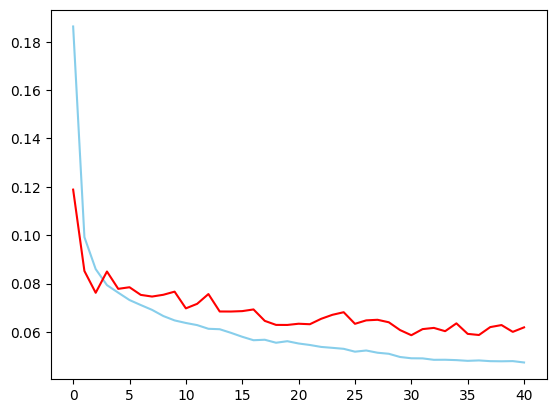

In [58]:
plt.plot(history.history['loss'],label='loss',color='skyblue')
plt.plot(history.history['val_loss'],label='val_loss',color='red')

In [59]:
reconstructions = model.predict(X_test)

errors = np.mean((X_test - reconstructions)**2, axis=(1,2))

threshold = np.percentile(errors, 95)

anomaly = (errors > threshold).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step


In [66]:
threshold

0.010205309832311917

In [ ]:
errors

In [60]:
t=0
for i in anomaly:
    if i==1:
        print(t)
    t=t+1

69
70
79
110
117
118
119


In [65]:
print("Mean error:", errors.mean())
print("Std error:", errors.std())

Mean error: 0.005754335879036097
Std error: 0.002529079158608084


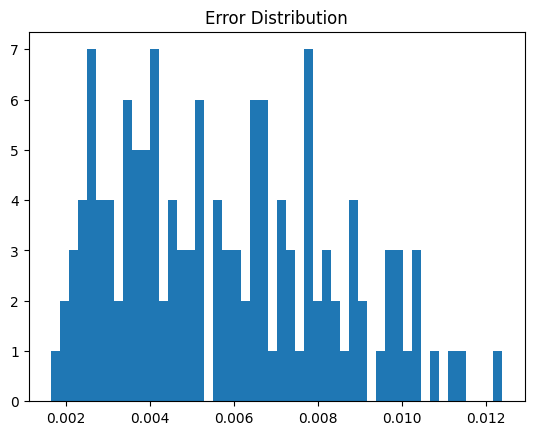

In [64]:
import matplotlib.pyplot as plt

plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.show()

<Axes: ylabel='Count'>

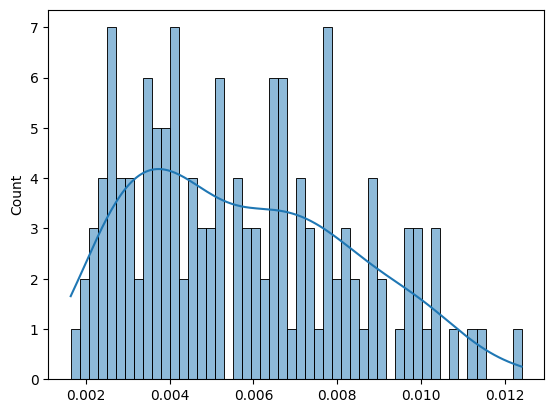

In [63]:
sns.histplot(errors,kde=True,bins=50)

ValueError: x and y must have same first dimension, but have shapes (6,) and (10,)

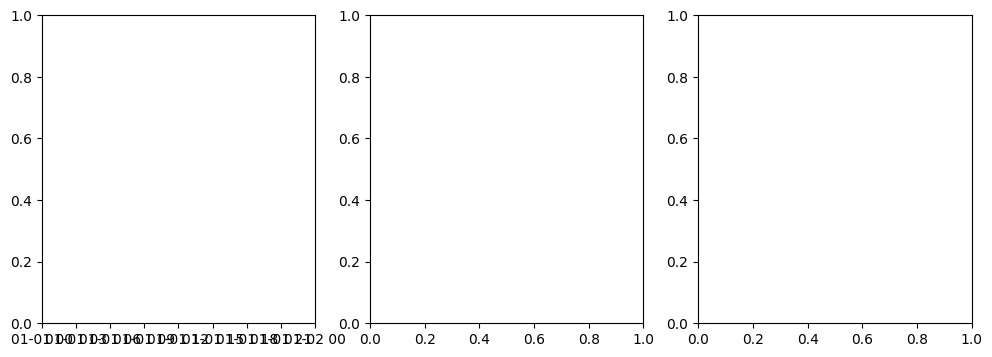

In [77]:
fig,ax=plt.subplots(1,3,figsize=(12,4))
idx = 79

actual = X_test[idx]
reconstructed = reconstructions[idx]

features=['NDVI', 'temperature', 'humidity']
for i in range(3):


    ax[i].plot(actual[:,i], label=f'Actual {features[i]}')
    ax[i].plot(reconstructed[:,i], label=f'Reconstructed {features[i]}')

    ax[i].legend()
    ax[i].set_title(f"Reconstruction {features[i]}")

plt.show()

In [ ]:
print("Anomaly %:", anomaly.mean()*100)

In [ ]:
anomaly_idx = np.where(anomaly == 1)[0]

for i in anomaly_idx[:5]:
    print("Index:", i)
    print("NDVI sequence:", X_test[i][:,0])
    print()

# try

In [67]:
errors = np.mean(abs(X_test - reconstructions), axis=(1))

threshold = np.percentile(errors, 95)

anomaly = (errors > threshold).astype(int)

In [68]:
pd.DataFrame(errors)

,0,1,2
0,0.032912,0.059986,0.043427
1,0.028153,0.059047,0.043281
2,0.056595,0.087388,0.048714
3,0.026082,0.056147,0.040878
4,0.026300,0.056515,0.041304
...,...,...,...
132,0.024774,0.083213,0.090623
133,0.025708,0.096784,0.092510
134,0.035602,0.070910,0.085334
135,0.033631,0.082293,0.083430


In [69]:
anomaly[anomaly==True]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [70]:
def date (df):
    for (lat, lon), group in df.groupby(['lat', 'lon']):
        group = group.sort_values('date')

        date = group['date'].values

        

    return date

In [71]:
date=date(df_test)
date

array(['2023-11-13T00:00:00.000000000', '2023-11-23T00:00:00.000000000',
       '2023-12-03T00:00:00.000000000', '2023-12-08T00:00:00.000000000',
       '2023-12-13T00:00:00.000000000', '2023-12-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [75]:
df['date']

array(['2023-01-17T00:00:00.000000000', '2023-01-20T00:00:00.000000000',
       '2023-01-25T00:00:00.000000000', ...,
       '2023-12-08T00:00:00.000000000', '2023-12-13T00:00:00.000000000',
       '2023-12-18T00:00:00.000000000'], dtype='datetime64[ns]')